Note: The group acknowledges that AI tools were used to refine the function syntax, specifically for tasks such as peak detection and labeling. All other parameter selections were made through trial-and-error and represent human judgment.

# AIM


1. Determine the fundamental frequency of vibration, anharmonicity constant and dissociation energy for the iodine molecule by using the absorption spectra of iodine.
2. Determine Dunham coefficient for the iodine molecule by using the fluorescence spectra of iodine



# Apparatus



1.   White light source
2. 532 nm laser
3. Iodine cell
4. Objective, Optical fibre and
Spectrometer



# Molecular Energy Levels
The total energy E of a molecules may be regarded as the sum of the individual contributions of rotational $E_r$, vibrational $E_v$, and electronic $E_e$ energies.
In wavenumber units, the total term value is written as $T = T_e + G(\nu) + F(J)$
where $T_e$ is the electronic term value, $G(\nu)$ is the vibrational term value, and $F(J)$ is the rotational term value. Currently, due to lack of resolution, we neglect the effects of rotational structure.

# Vibrational Energy Levels
The vibrational motion of a diatomic molecule is anharmonic, and is approximated by:

$G(\nu) = \omega_0ν - ω\chi_0ν^2$

where $\omega_0$ is the fundamental vibrational frequency, $\chi_0$ is the anharmonicity constant, $\nu = 0, 1, 2...$ is the vibrational quantum number.
The spacing between adjacent vibrational levels is

$ΔG(\nu) = G(ν + 1) - G(\nu) = \omega_0 - \omega_0 \chi_0- 2\omega_0\chi_0ν$

# Absorption
A molecule possesses many electronic states. There are many vibrational states corresponding to each electronic state and along with these vibrational states there are many rotational states. The transitions occur according to selection rules. Consider two electronic states: a lower (or a ground) electronic states and an upper (or first excited) electronic state. The vibrational quantum number is denoted for υ” for ground state and those in the upper state by υ’. A transition from υ’ and υ” level is denoted as (υ’, υ”) and is called as (υ’, υ”) vibrational band. For example, a transition from υ’=0 to υ” =0 is called as (0,0) band. (Corresponding to these vibrational transitions, there are  rotational transitions which appear as degradation to each vibrational band)

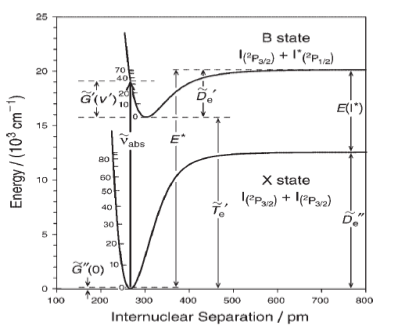

Figure 1: Potential energy curve with respect to intermolecular distance, just to show the
vibration levels in the electronic state

# Plotting Analysis
The vibrational level spacing $ΔG(\nu)$ is obtained from the measured absorption peaks. A plot of $ΔG(\nu)$ versus $\nu$ should yield a straight line, whose intercept gives us $\omega_0 - \omega_0 \chi_0$, and slope gives us $-2\omega_0\chi_0$.




# Fluorescence
The iodine fluorescence experiment provides insights into the electronic, vibrational, and
rotational energy levels of iodine molecules. By analyzing the emitted fluorescence spectrum,
one can determine important molecular constants such as Dunham coefficients.
Most of the precise potential curves have been derived from experimental data with the aid of
different computational schemes. They rely on semi-empirical methods like the WKB procedure,
an approximation method for the solution of the one-dimensional Schrödinger equation named
after the initials of the inventors Wentzel, Kramers, and Brillouin.


# Determination of Ground State Vibrational  Energies

The energy of the emitted photon is obtained from the measured wavelength as $1/λ$.
The vibrational energy of the ground state level $\nu^"$ is then calculated as:
$E(\nu^") = E_{532} - E(\nu' →\nu")$
where $E_{532}$ is the excitation energy corresponding to 532nm (wavelength of the diode pump laser)

# Dunham Expansion

The vibrational energy levels of the ground electronic state are expressed using the Dunham expansion:

$E(\nu") = Y_{00} + Y_{10}(\nu" + \frac{1}{2}) + Y_{20}(\nu" + \frac{1}{2})^2 + Y_{30}(\nu" + \frac{1}{2})^3 + ⋯$


# Analysis

## Part I

In [152]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [153]:
data = "AbsorptionGroup15.csv"
peak_data = "peaks.csv"

cutoff_wavelength = 500 # nm as mentioned in manual
upper_bound = 550 # nm, + 5 nm from what was mentioned in manual
prominence_bound = 0.17
ref_wavelength = 543.359
ref_number = 26

In [154]:
df = pd.read_csv(data)
wavelength = np.array(df["Wavelength [nm]"].values)
spectra = np.array(df["spectra"].values)

# filtering
mask = (wavelength > cutoff_wavelength) & (wavelength < upper_bound)
w = wavelength[mask]
s = spectra[mask]

# peak finding function
peaks, properties = find_peaks(s, prominence=prominence_bound)
peak_wavelengths = w[peaks]
peak_intensities = s[peaks]

# sorting
order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[order]
peak_intensities = peak_intensities[order]

# assignment of vibrational quantum numbers, from manual 543.47 ~ (26,0)
ref_matches = np.where(peak_wavelengths==ref_wavelength)[0]
ref_index = ref_matches[0]
v_numbers = np.zeros(len(peak_wavelengths), dtype=int)
v_numbers[ref_index] = ref_number

# increasing labels below the ref
for i in range(ref_index - 1, -1, -1):
    v_numbers[i] = v_numbers[i + 1] + 1

# decreasing labels above the ref
for i in range(ref_index + 1, len(v_numbers)):
    v_numbers[i] = v_numbers[i - 1] - 1

peak_table = pd.DataFrame({
    "Vibrational quantum number": v_numbers,
    "Wavelength (nm)": peak_wavelengths,
    "Intensity": peak_intensities})
peak_table.to_csv(peak_data, index=False)
print(peak_table)

    Vibrational quantum number  Wavelength (nm)  Intensity
0                           36          523.984   1.400492
1                           35          525.628   1.432011
2                           34          527.269   1.444273
3                           33          529.042   1.411960
4                           32          530.880   1.389401
5                           31          532.782   1.406922
6                           30          534.746   1.366423
7                           29          536.773   1.405335
8                           28          538.930   1.377248
9                           27          541.147   1.393081
10                          26          543.359   1.368150
11                          25          545.763   1.358873
12                          24          548.227   1.338093


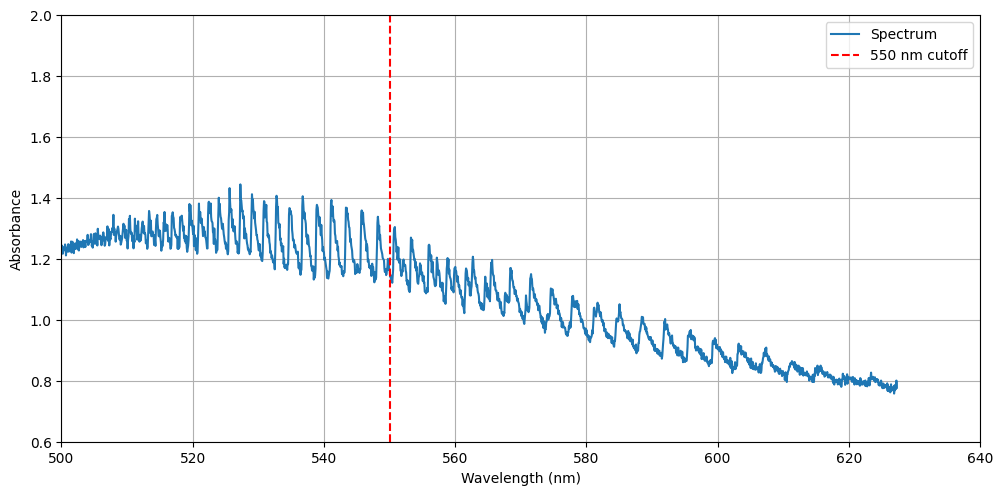

In [155]:
plt.figure(figsize=(10, 5))
plt.plot(wavelength, spectra, label="Spectrum")
plt.axvline(upper_bound, linestyle="--", color='red', label="550 nm cutoff")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.xlim(500,640)
plt.ylim(0.6,2)
plt.show()

In [156]:
peak_data = "peaks.csv"
table = "final.csv"

In [157]:
df = pd.read_csv(peak_data)

# Sorting by vibrational quantum number
df = df.sort_values("Vibrational quantum number").reset_index(drop=True)
v = df["Vibrational quantum number"].values
wavelength = np.array(df["Wavelength (nm)"].values)

# G
G = 1e7/wavelength # cm^-1

# first and second difference
dG = np.full_like(G,np.nan)
d2G = np.full_like(G,np.nan)
for i in range(len(G) - 1):
    dG[i] = G[i+1] - G[i]

for i in range(len(G) - 2):
    d2G[i] = dG[i+1] - dG[i]

df["G (cm^-1)"] = G
df["dG (cm^-1)"] = dG
df["d2G (cm^-1)"] = d2G
df.to_csv(table, index=False)
print(df)


    Vibrational quantum number  Wavelength (nm)  Intensity     G (cm^-1)  \
0                           24          548.227   1.338093  18240.619306   
1                           25          545.763   1.358873  18322.971693   
2                           26          543.359   1.368150  18404.038582   
3                           27          541.147   1.393081  18479.267186   
4                           28          538.930   1.377248  18555.285473   
5                           29          536.773   1.405335  18629.849117   
6                           30          534.746   1.366423  18700.467138   
7                           31          532.782   1.406922  18769.402870   
8                           32          530.880   1.389401  18836.648583   
9                           33          529.042   1.411960  18902.090949   
10                          34          527.269   1.444273  18965.651309   
11                          35          525.628   1.432011  19024.861689   
12          

In [158]:
# least square fitting
mask_dG = ~np.isnan(dG)
mask_d2G = ~np.isnan(d2G)

m1, c1 = np.polyfit(v[mask_dG], dG[mask_dG], 1)
fit_dG = m1 * v + c1
m2, c2 = np.polyfit(v[mask_d2G], d2G[mask_d2G], 1)
fit_d2G = m2 * v + c2

print(f"dG fit: slope = {m1:.4f}, offset = {c1:.4f}")
print(f"d2G fit: slope = {m2:.4f}, offset = {c2:.4f}")

dG fit: slope = -2.1125, offset = 132.6473
d2G fit: slope = 0.0757, offset = -4.2548


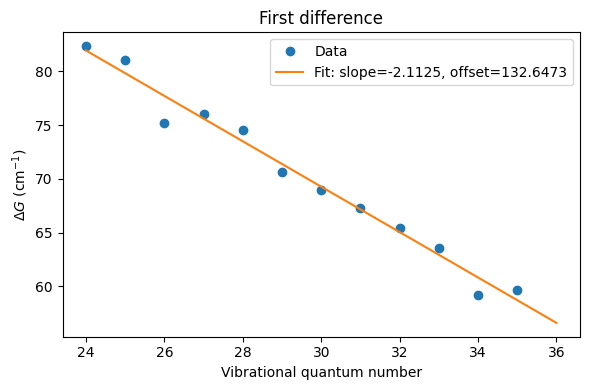

In [159]:
# plot1: dG vs v
plt.figure(figsize=(6,4))
plt.plot(v, dG, "o", label="Data")
plt.plot(v, fit_dG, "-", label=f"Fit: slope={m1:.4f}, offset={c1:.4f}")
plt.xlabel("Vibrational quantum number")
plt.ylabel(r"$\Delta G$ (cm$^{-1}$)")
plt.title("First difference")
plt.legend()
plt.tight_layout()
plt.show()

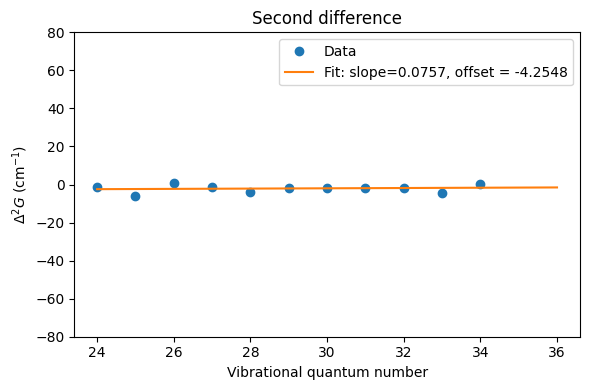

In [160]:
#plot2: d2G vs v
plt.figure(figsize=(6,4))
plt.plot(v, d2G, "o", label="Data")
plt.plot(v, fit_d2G, "-", label=f"Fit: slope={m2:.4f}, offset = {c2:.4f}")
plt.xlabel("Vibrational quantum number")
plt.ylabel(r"$\Delta^2 G$ (cm$^{-1}$)")
plt.title("Second difference")
plt.legend()
plt.ylim(-80,80)
plt.tight_layout()
plt.show()

## Part 2


In [161]:
data = "fluorescence.txt"
final = "fluorescence_final.csv"

In [162]:
threshold_prominence = 400
ref_wavelength= 532.0 # nm
data = pd.read_csv(data, sep=r"\s+", header=None,names=["Wavelength (nm)", "Intensity"])

wavelength  = data["Wavelength (nm)"].values
I = data["Intensity"].values

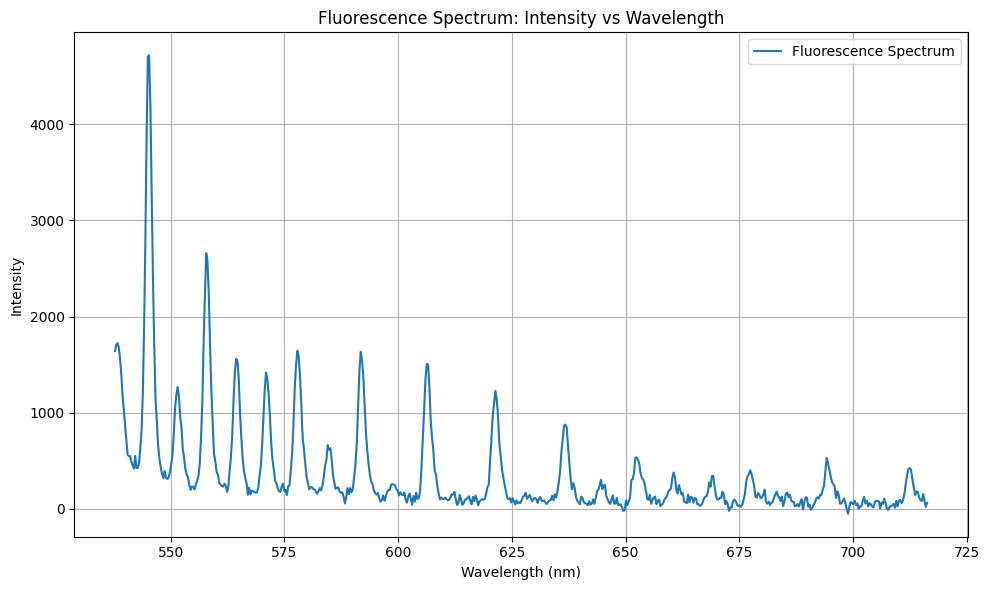

In [163]:
plt.figure(figsize=(10, 6))
plt.plot(wavelength, I, label='Fluorescence Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Fluorescence Spectrum: Intensity vs Wavelength')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [164]:
# peak finder
peaks, props = find_peaks(I, prominence=threshold_prominence)
peak_wavelength  = wavelength [peaks]
peak_I = I[peaks]

# labeling
order = np.argsort(peak_wavelength)
peak_wavelength = peak_wavelength[order]
peak_I = peak_I[order]
v = np.arange(1, len(peak_wavelength) + 1)

In [165]:
# wavenumber calculation
E = 1e7/peak_wavelength
E_532 = 1e7/ref_wavelength
E_nu = E_532 - E
df = pd.DataFrame({
    "v": v,
    "Wavelength (nm)": peak_wavelength ,
    "Intensity": peak_I,
    "E (cm^-1)": E,
    "E_532 - E(cm^-1)": E_nu
})
df.to_csv(final, index=False)
print(df)

     v  Wavelength (nm)  Intensity     E (cm^-1)  E_532 - E(cm^-1)
0    1          545.237   4720.113  18340.648195        456.344286
1    2          551.504   1266.510  18132.234762        664.757720
2    3          557.797   2660.063  17927.669027        869.323455
3    4          564.375   1560.310  17718.715393       1078.277088
4    5          570.954   1417.150  17514.545830       1282.446651
5    6          577.831   1644.016  17306.098150       1490.894331
6    7          584.506    660.986  17108.464242       1688.528240
7    8          591.762   1633.481  16898.685620       1898.306861
8    9          606.275   1507.510  16494.165189       2302.827292
9   10          621.367   1225.692  16093.548579       2703.443902
10  11          636.750    875.506  15704.750687       3092.241794
11  12          652.423    532.185  15327.479258       3469.513223
12  13          677.384    400.302  14762.675233       4034.317248
13  14          694.218    528.521  14404.697084       4392.29

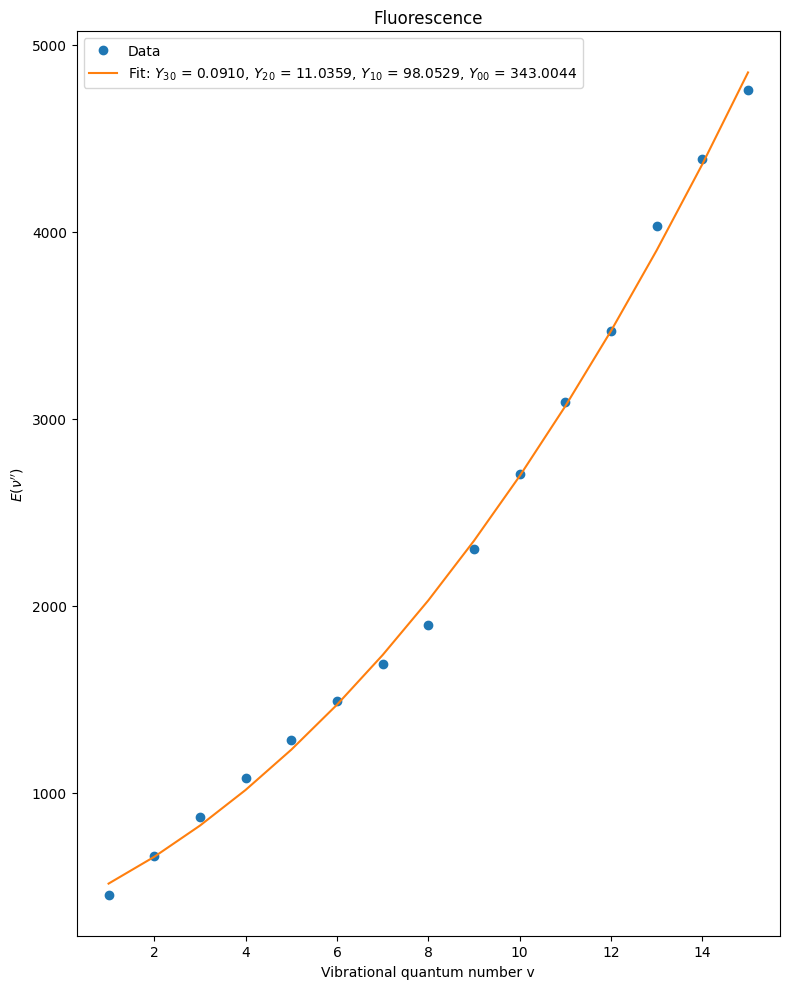

In [167]:
# least square fit
a, b, c, d = np.polyfit(v+0.5, E_nu, 3)
fit = a*(v + 0.5)**3 + b*(v+0.5)**2 + c*(v+0.5) + d

plt.figure(figsize=(8,10))
plt.plot(v, E_nu, "o", label="Data")
plt.plot(v, fit, "-", label=rf"Fit: $Y_{{30}}$ = {a:.4f}, $Y_{{20}}$ = {b:.4f}, $Y_{{10}}$ = {c:.4f}, $Y_{{00}}$ = {d:.4f}")
plt.xlabel("Vibrational quantum number v")
plt.ylabel(r"$E({\nu''})$")
plt.title("Fluorescence")
plt.legend()
plt.tight_layout()
plt.show()

### Calculation and Results




### Absorption Spectrum Analysis

Steps:
We know that from theory:
$$\Delta G = (\omega_0 - \omega_0 \chi_0) - (2\omega_0 \chi_0) v$$

From the plot number 1, we get -

Slope ($m$) : $-2\omega_0 \chi_0 = -2.1125$

Intercept ($c$) : $\omega_0 - \omega_0 \chi_0 = 132.6473$

This gives

Fundamental Frequency ($\omega_0$) = $132.6473 + 2.1125/2 = 133.704 \, cm^{-1}$

Anharmonicity Constant ($\chi_0$) = $7.89 \times 10^{-3}$

Dissociation Energy ($D_0$): $\frac{(\omega_0)^2}{4\omega_0 \chi_0} = 4232.187 \, \text{cm}^{-1}$

### Fluorescence Spectrum Analysis

Steps:

We know from theory:
$$E(\nu") = Y_{00} + Y_{10}(\nu" + \frac{1}{2}) + Y_{20}(\nu" + \frac{1}{2})^2 + Y_{30}(\nu" + \frac{1}{2})^3 + ⋯$$

From the plot, we get:

$Y_{00} = 343.0044 \, \text{cm}^{-1}$

$Y_{10} = 98.0529 \, \text{cm}^{-1}$

$Y_{20} = 11.0359 \, \text{cm}^{-1}$

$Y_{30} = 0.0910 \, \text{cm}^{-1}$



These are the values of the four Dunham constants

